# count points function

In [1]:
import numpy as np

In [3]:
np.linspace(-200,200,21)

array([-200., -180., -160., -140., -120., -100.,  -80.,  -60.,  -40.,
        -20.,    0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,
        160.,  180.,  200.])

In [4]:
xi, xf, nx = -200, 200, 21
yi, yf, ny = 0, 0, 1
ei, ef, ne = 20e3, 20e3, 1

In [5]:
x = np.linspace(xi, xf, nx)
y = np.linspace(yi, yf, ny)
e = np.linspace(ei, ef, ne)

In [10]:
maskx = (xi-200 <= x) & (x <= xf+200)

In [11]:
np.sum(maskx)

np.int64(21)

In [ ]:
# todo: aceitar apenas numero, para poder contar so um plano ou segmento
def count_points(self,
        xlim = None,
        ylim = None,
        elim = None
    ) -> int:

    x = np.linspace(xi, xf, nx)
    y = np.linspace(yi, yf, ny)
    e = np.linspace(ei, ef, ne)

    if not xlim: xlim = (xi, xf)
    if not ylim: ylim = (yi, yf)
    if not elim: elim = (ei, ef)

    maskx = (xlim[0] <= x) & (x <= xlim[1])
    masky = (ylim[0] <= y) & (y <= ylim[1])
    maske = (elim[0] <= e) & (e <= elim[1])

    return np.sum(maskx) * np.sum(masky) * np.sum(maske)

In [12]:
False is None

False

In [13]:
1 == True

True

In [14]:
1 is True

<>:1: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:1: SyntaxWarning: "is" with a literal. Did you mean "=="?
C:\Users\juven\AppData\Local\Temp\ipykernel_18684\3482963539.py:1: SyntaxWarning: "is" with a literal. Did you mean "=="?
  1 is True


False

In [15]:
import srwpy.srwlib as srw

In [16]:
mesh = srw.SRWLRadMesh()

mesh.xStart = -200
mesh.xFin = 200
mesh.nx = 21

mesh.yStart = -10
mesh.yFin = 10
mesh.ny = 3

mesh.eStart = 20e3
mesh.eFin = 20e3
mesh.ne = 1

In [17]:
def count_points(
        xlim = True,
        ylim = True,
        elim = True
    ) -> int:
    """Counts the number of points within specified limits across
    horizontal and vertical positions and energy of the wavefront.

    Parameters
    ----------
    xlim : array or bool, optional
        Horizontal range.
    ylim : array or bool, optional
        Vertical range.
    elim : array or bool, optional
        Energy range.

    Notes
    -----
    By default, True, the full range of points at some dimension are
    counted. If the dimension limits is False, it is not counted.
    """

    counts = 1

    for u, ulim in zip(['x', 'y', 'e'], [xlim, ylim, elim]):
        ui = getattr(mesh,f'{u}Start')
        uf = getattr(mesh,f'{u}Fin')
        nu = getattr(mesh,f'n{u}')
        uarr = np.linspace(ui,uf,nu)

        if ulim:
            if ulim is True: ulim = (ui, uf)
            mask = (ulim[0] <= uarr) & (uarr <= ulim[1])
            counts *= np.sum(mask)

    return counts

In [21]:
count_points(xlim=(-150,-90))

np.int64(9)

# plot functions

In [1]:
import numpy as np
from matplotlib import pyplot as plt

import srwpy.srwlib as srw

import srwave

In [3]:
print(srw.helpCalcIntFromElecField)

CalcIntFromElecField(_arI, _inWfr, _inPol, _inIntType, _inDepType, _inE, _inX, _inY)
function calculates/"extracts" Intensity from pre-calculated Electric Field
:param _arI: output resulting Intensity array (should be allocated in Python script before calling this function)
:param _inWfr: input pre-calculated Wavefront structure (instance of SRWLWfr)
:param _inPol: input switch specifying polarization component to be extracted:
               =0 -Linear Horizontal; 
               =1 -Linear Vertical; 
               =2 -Linear 45 degrees; 
               =3 -Linear 135 degrees; 
               =4 -Circular Right; 
               =5 -Circular Left; 
               =6 -Total
:param _inIntType: input switch specifying "type" of a characteristic to be extracted:
               =0 -"Single-Electron" Intensity; 
               =1 -"Multi-Electron" Intensity; 
               =2 -"Single-Electron" Flux; 
               =3 -"Multi-Electron" Flux; 
               =4 -"Single-Electron" Radiation

spatial bending

In [2]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = srwave.BendingMagnet(B=0.5642,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

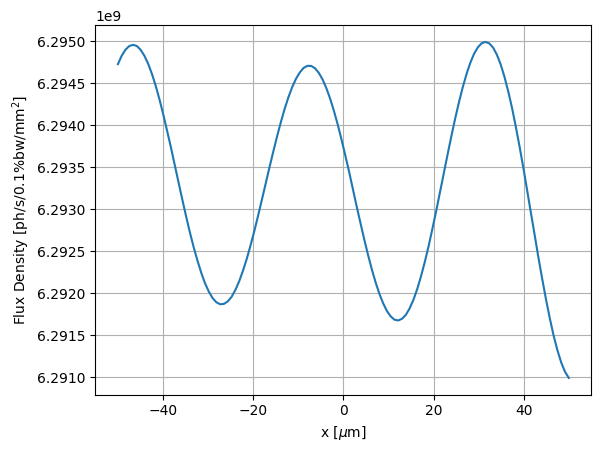

In [3]:
SR.plot_intensity(coords='x',energy=Eph,Y=0)

In [4]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = srwave.BendingMagnet(B=0.5642,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

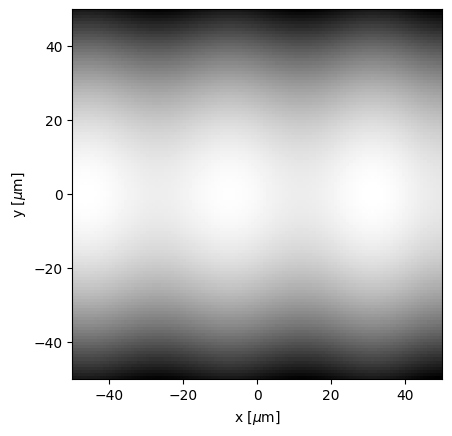

In [5]:
SR.plot_intensity(coords='xy',energy=Eph)

undulator spatial

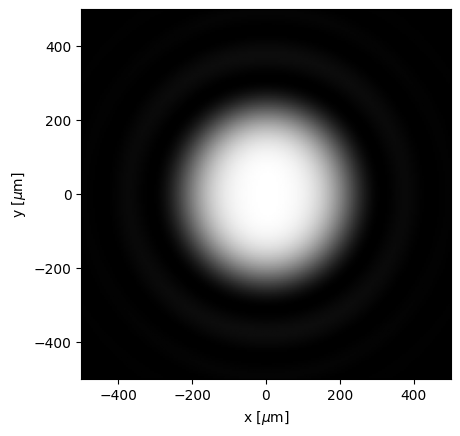

In [7]:
und = srwave.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = srwave.MagnetCnt(magnets=[und],fieldtype='undulator')

w = np.linspace(-5e-4,5e-4,200)
Eph = und.harmonic_energy(harmn=1,E=3e9,theta=0)

SR = srwave.SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

SR.plot_intensity(coords='xy',energy=Eph)

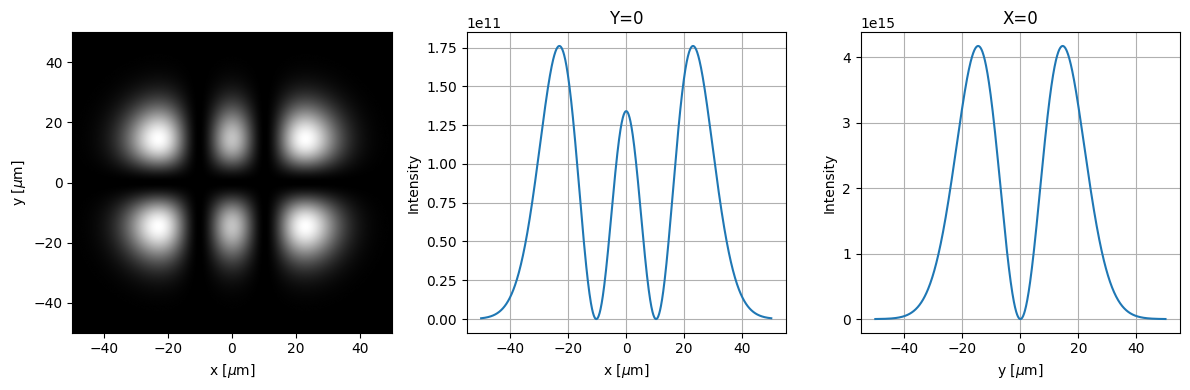

In [8]:
# TEM21 #

Eph = 8e3
w = np.linspace(-50,50,1000) * 1e-6

GR = srwave.GaussianRadiation(energy=Eph,x=w,y=w,d=2)
GR.gaussianbeam.set_mode(modex=2,modey=1)
GR.calc_wfr()

plt.figure(figsize=(12,4))

ax_xy = plt.subplot(1,3,1)
ax_x = plt.subplot(1,3,2)
ax_y = plt.subplot(1,3,3)

GR.plot_intensity(coords='xy', energy=Eph, ax=ax_xy, aspect='auto')
GR.plot_intensity(coords='x', energy=Eph, Y=0, ax=ax_x,
                  title='Y=0', ylabel='Intensity')
GR.plot_intensity(coords='y', energy=Eph, X=0, ax=ax_y,
                  title='X=0', ylabel='Intensity')

plt.tight_layout()
plt.show()

spectum bending

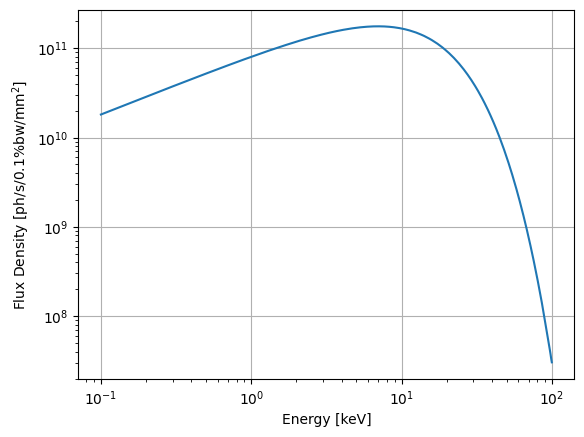

In [9]:
energy = np.linspace(0.1,100,500)*1e3

bm = srwave.BendingMagnet(B=1.4,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

SR.plot_spectrum(xscale='log',yscale='log')

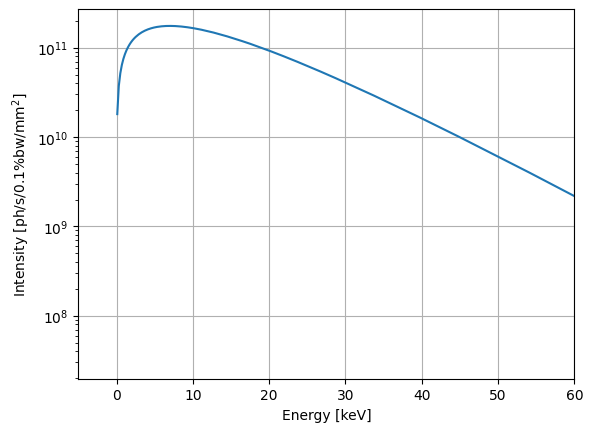

In [10]:
arrI, [rangee] = SR.calc_intensity(coords='e', energy=0, X=0, Y=0, polarization='total', calctype='SE')

ax = plt.subplot()

ax.plot(energy*1e-3,arrI)
ax.set(xlabel='Energy [keV]', ylabel=r'Intensity [ph/s/0.1%bw/mm$^2$]',yscale='log',xlim=[-5,60])
ax.grid()
plt.show()

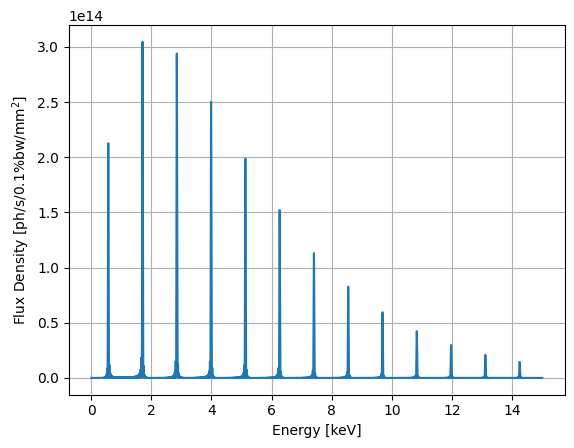

In [11]:
und = srwave.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = srwave.MagnetCnt(magnets=[und],fieldtype='undulator')

energy = np.linspace(0.01,15,7000)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy,E=3e9,theta=0)

SR = srwave.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

SR.plot_spectrum()

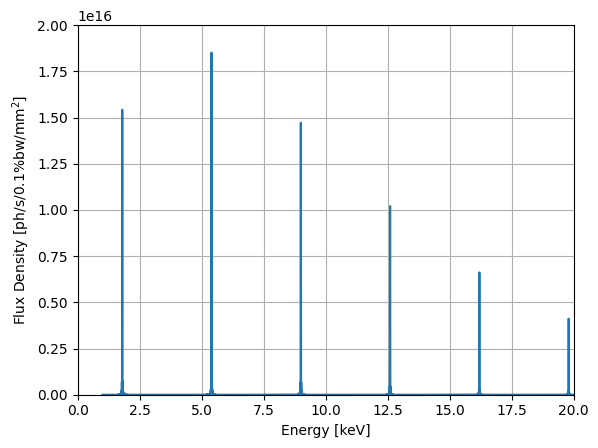

In [ ]:
beam = srwave.radiation.Beam(I=500e-3, E=3e9)
und = srwave.Undulator(period_length=20e-3,nr_periods=150,Ky=1.65776086,Kx=0)
fields = srwave.MagnetCnt(magnets=[und],fieldtype='undulator')

energy = np.linspace(1,20,7000) * 1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy,E=3e9,theta=0)

SR = srwave.SynchrotronRadiation(energy=energy,d=20,x=0,y=0,fields=fields, beam=beam)
SR.calc_wfr()

SR.plot_spectrum(xlim=[0, 20], ylim=[0, 2e16])

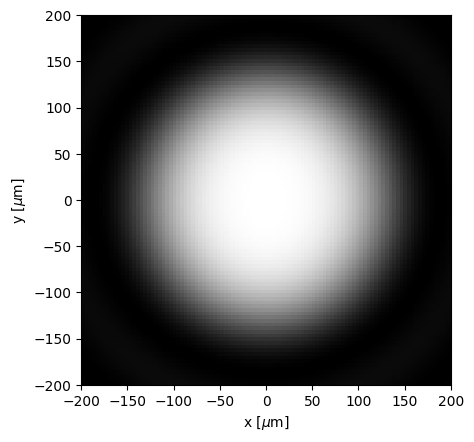

In [4]:
beam = srwave.radiation.Beam(I=500e-3, E=3e9)
und = srwave.Undulator(period_length=20e-3,nr_periods=150,Ky=1.65776086,Kx=0)
fields = srwave.MagnetCnt(magnets=[und],fieldtype='undulator')

Eph = 9e3
w = np.linspace(-200, 200, 101) * 1e-6

SR = srwave.SynchrotronRadiation(energy=Eph,d=20,x=w,y=w,fields=fields, beam=beam)
SR.calc_wfr()

SR.plot_intensity(coords='xy', energy=Eph)

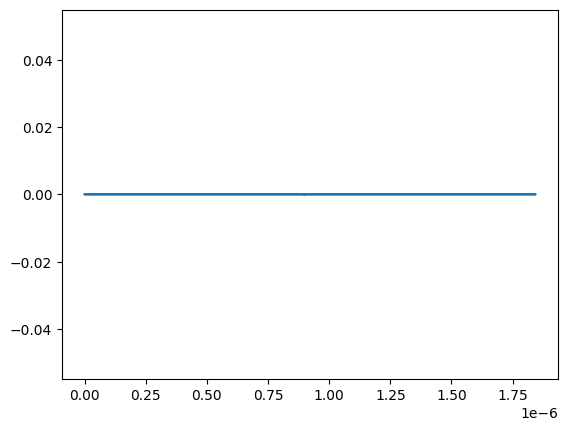

In [9]:
beam = srwave.radiation.Beam(I=500e-3, E=3e9)
und = srwave.Undulator(period_length=20e-3,nr_periods=150,Ky=1.65776086,Kx=0)
fields = srwave.MagnetCnt(magnets=[und],fieldtype='undulator')

partraj = fields.calc_trajectory()

plt.plot(partraj.arX, partraj.arY)
plt.show()

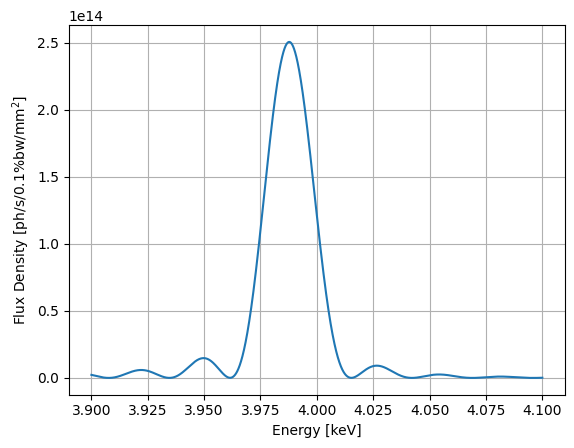

In [ ]:
und = srwave.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = srwave.MagnetCnt(magnets=[und],fieldtype='undulator')

energy = np.linspace(4-0.1,4+0.1,7000)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy,E=3e9,theta=0)

SR = srwave.SynchrotronRadiation(energy=energy,d=10,x=0,y=0,fields=fields)
SR.calc_wfr()

SR.plot_spectrum(xunitprefix='k')

In [20]:
und = srwave.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
magnets = (und,)
magnets = list(magnets)

In [29]:
None or 3*[2*[0]]

[[0, 0], [0, 0], [0, 0]]

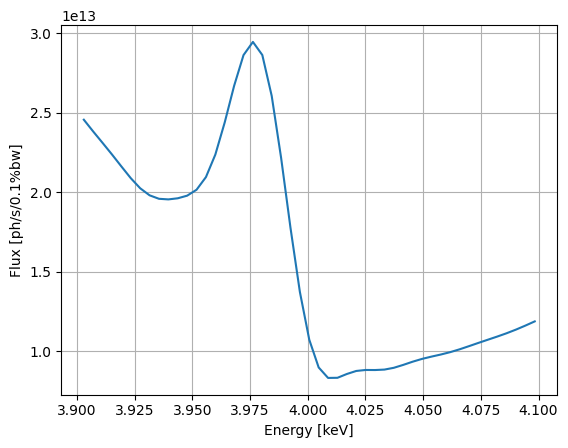

In [12]:
und = srwave.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = srwave.MagnetCnt(magnets=[und],field_type='undulator')

w = np.linspace(-5e-4,5e-4,200)
energy = np.linspace(4-0.1,4+0.1,50)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy,E=3e9,theta=0)

SR = srwave.SynchrotronRadiation(energy=energy,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

SR.plot_flux()

phase

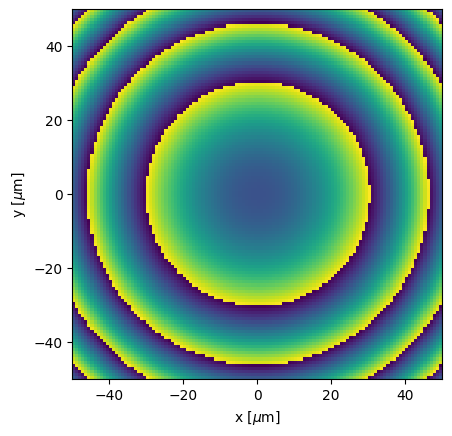

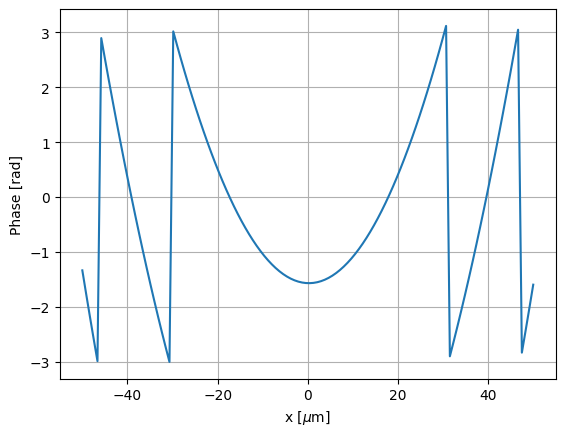

In [27]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = srwave.BendingMagnet(B=0.5642,L=3)
fields = srwave.MagnetCnt(magnets=[bm],field_type='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

SR.plot_electric_field(part='phase',coords='xy', energy=Eph, cmap='viridis')

SR.plot_electric_field(part='phase',coords='x', energy=Eph, Y=0)

In [15]:
srwave.radiation.RadiationSource._infer_units(
    coords='x',
    calctype='re',
    xunitprefix='',
    yunitprefix='',
    normalize=False
)

['x [m]', 'Re E [sqrt(ph/s/0.1%bw/mm$^2$)]']

# matplotlib plots details

In [2]:
import numpy as np
from matplotlib import pyplot as plt

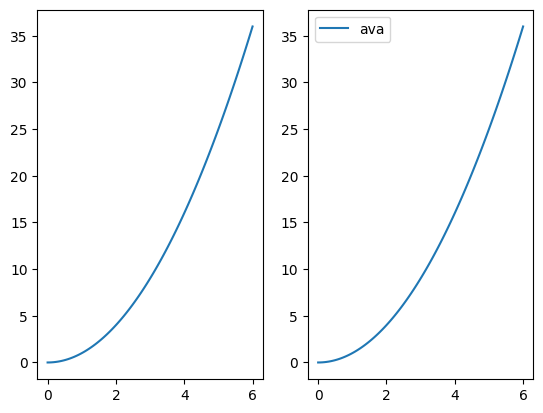

In [16]:
x = np.linspace(0,6,100)
y = x**2

ax = plt.subplot(1,2,1)
ax.plot(x,y)

ax = plt.subplot(1,2,2)
ax.plot(x,y,label='ava')
# ['xlim', 'ylim', 'xscale', 'yscale', 'title', 'xlabel', 'ylabel']
# ax.set(label='ava')
ax.legend()
plt.show()

# array equally spaced

In [2]:
import numpy as np

In [3]:
arr1 = np.array([1,2,3,4,5,6])
arr2 = np.array([1,3,7,14,20])

print(np.diff(arr1))
print(np.diff(arr2))

[1 1 1 1 1]
[2 4 7 6]


In [4]:
a = np.array(2)
a

array(2)

In [10]:
np.atleast_1d(2)

array([2])

In [ ]:
np.allclose()

generic dimension:
set_mesh: coord
IntFromElecField: coord
plot_result: u or u, v

coord vai ser relativo a string e u relativo ao array

# allocate mesh after uStart, uFin, ...

In [136]:
import time
import copy
from array import array

import numpy as np
from matplotlib import pyplot as plt
from scipy import constants

import srwpy.srwlib as srw
import srwpy.srwlpy as srwl

In [51]:

B = 0.5642
LeffBM = 2
bm = srw.SRWLMagFldM(B, 1, 'n', LeffBM)
magcnt = srw.SRWLMagFldC([bm], [0], [0], [0])

partraj = 0

precisions = [2, 0.005, 0, 0, 50000, 1, 0.0]

wfr = srw.SRWLWfr()
wfr.allocate(1,120,120) 
wfr.mesh.eStart = 20e3 #initial energy
wfr.mesh.eFin   = 20e3 #final energy
wfr.mesh.xStart = -50e-6 #initial horizontal position [m]
wfr.mesh.xFin   = 50e-6 #final horizontal position [m]
wfr.mesh.yStart = -50e-6 #initial vertical position [m]
wfr.mesh.yFin   = 50e-6 #final vertical position [m]
wfr.mesh.zStart = 10 #Longitudinal position for initial wavefront [m]
wfr.partBeam.Iavg = 0.1
wfr.partBeam.partStatMom1.gamma = 3/0.51099892e-3
wfr = srwl.CalcElecFieldSR(wfr, partraj, magcnt, precisions)

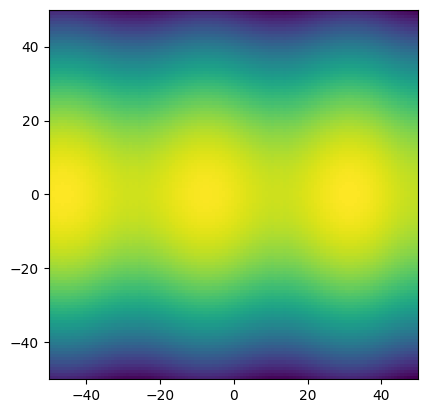

In [52]:
arrI = array('f',[0]*wfr.mesh.nx*wfr.mesh.ny)
srwl.CalcIntFromElecField(arrI, wfr, 6, 0, 3, wfr.mesh.eStart, 0, 0)
arrI = np.array(arrI).reshape(wfr.mesh.ny,wfr.mesh.nx)

limits = [-50,50,-50,50]

plt.imshow(arrI,extent=limits)
plt.show()

# srw wfr allocate func

In [58]:
20 * 800 * 800

12800000

In [132]:
times = []
for _ in range(1000):
    t0 = time.perf_counter()
    arr = array('f', [0]*100000)
    t1 = time.perf_counter()
    times.append((t1-t0)*1000)
print(np.mean(times),'ms')

5.518055101973005 ms


In [ ]:
times = []
for _ in range(1000):
    t0 = time.perf_counter()
    arr = np.zeros(100000, dtype=np.float32)
    t1 = time.perf_counter()
    times.append((t1-t0)*1000)
print(np.mean(times),'ms')

0.014064200920984149 ms


CONCLUSÃO: alocar com np.zeros é muito mais eficiente do que com array.array

In [134]:
e = 1; x = 2; y = 3

for u in [e, x, y]:
    print(u.__name__)
    u = np.atleast_1d(u)
    print(u)


AttributeError: 'int' object has no attribute '__name__'

In [147]:
def uti_array_alloc(_type, _n, _list_base=[0]): #OC14042019
#def srwl_uti_array_alloc(_type, _n):

    # import numpy as np #OCTEST OC02112022
    # resAr = np.zeros(_n, dtype=float) #OCTEST OC02112022
    # resAr = array(_type, _list_base*_n) #OCTEST OC02112022

    #nPartMax = 1000000 #OCTEST OC02112022
    nPartMax = 10000 #to tune
    #nPartMax = 3000000 #to tune
    
    #print('srwl_uti_array_alloc: array requested:', _n)
    lenBase = len(_list_base) #OC14042019
    nTrue = _n*lenBase #OC14042019
    
    if(nTrue <= nPartMax): return array(_type, _list_base*_n)
    #if(_n <= nPartMax): return array(_type, [0]*_n)
        #resAr = array(_type, [0]*_n)
        #print('Array requested:', _n, 'Allocated:', len(resAr))
        #return resAr

    print('passou do new limite 10_000')

    nPartMax_d_lenBase = int(nPartMax/lenBase) #OC14042019

    nEqualParts = int(_n/nPartMax_d_lenBase) #OC14042019
    #nEqualParts = int(_n/nPartMax)

    nResid = int(_n - nEqualParts*nPartMax_d_lenBase) #OC14042019
    #nResid = int(_n - nEqualParts*nPartMax)

    resAr = array(_type, _list_base*nPartMax_d_lenBase) #OC14042019
    #resAr = array(_type, [0]*nPartMax)

    if(nEqualParts > 1):
        auxAr = copy.deepcopy(resAr)
        for i in range(nEqualParts - 1): 
            resAr.extend(auxAr)
    if(nResid > 0):
        auxAr = array(_type, _list_base*nResid) #OC14042019
        #auxAr = array(_type, [0]*nResid)
        resAr.extend(auxAr)

    #print('Array requested:', _n, 'Allocated:', len(resAr))
    
    return resAr


In [148]:
arr = uti_array_alloc('f', 10203010)
len(arr)

passou do new limite 10_000


10203010

CONCLUSÃO: a função de allocate do SRWLWfr define mesh.ne, mesh.nx, mesh.ny e também, por padrão, inicializa wfr.arEx e wfr.arEy, mas também wfr.arMomX e wfr.arMomY, com função separada, a srwl_uti_array_alloc, que apenas tenta construir uma lógica de alocar mais rapidamente array.array de zeros quando o numero de elementos excede 10_000_000, mas no fim apenas cria array de zeros da quantidade passada

# flux manual calc

In [12]:
import numpy as np
from matplotlib import pyplot as plt

import srwave

In [24]:
und = srwave.Undulator(period_length=50e-3, nr_periods=20, Kv=2, Kh=0)
fields = srwave.MagnetCnt(magnets=und, fieldtype='undulator')

w = np.linspace(-5e-4, 5e-4, 100)
energy = np.linspace(4-0.1,4+0.1,50)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy, E=3e9, theta=0)

SR = srwave.SynchrotronRadiation(energy=energy, d=5, x=w, y=w, fields=fields)
SR.calc_wfr()

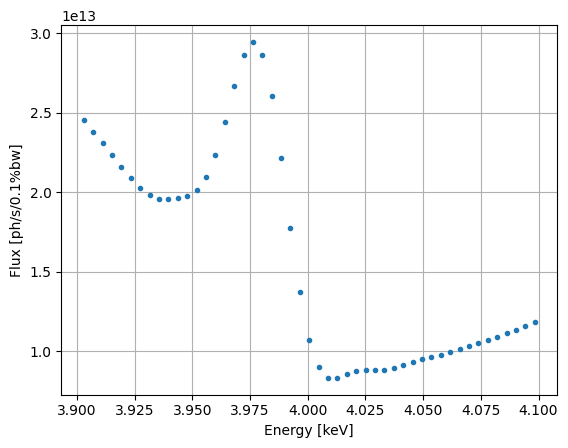

In [25]:
arrF, [rangee] = SR.calc_flux(polarization='total', calctype='SE')

plt.plot(energy*1e-3, arrF, '.')
plt.xlabel('Energy [keV]')
plt.ylabel(r'Flux [ph/s/0.1%bw]')
plt.grid()
plt.show()

In [21]:
idxmax = np.argmax(arrF)
energy[idxmax], arrF[idxmax]

(np.float64(3976.2537897709453), np.float32(29459583000000.0))

In [29]:
arrImax, [rangex, rangey] = SR.calc_intensity(coords='xy', energy=energy[idxmax])
FImax = np.sum(arrImax)
Fmax = arrF[idxmax]

arrImax_p3, [rangex, rangey] = SR.calc_intensity(coords='xy', energy=energy[idxmax+3])
FImax_p3 = np.sum(arrImax_p3)
Fmax_p3 = arrF[idxmax+3]

In [46]:
FImax, Fmax, FImax/Fmax

(np.float32(2.9121734e+17), np.float32(29459583000000.0), np.float32(9885.317))

In [47]:
FImax_p3, Fmax_p3, FImax_p3/Fmax_p3

(np.float32(2.2002356e+17), np.float32(22174128000000.0), np.float32(9922.535))

In [43]:
arrFI = []
for Eph in energy:
    arrI, [rangex, rangey] = SR.calc_intensity(coords='xy', energy=Eph)
    FI = np.sum(arrI)
    arrFI.append(FI)
arrFI = np.array(arrFI)

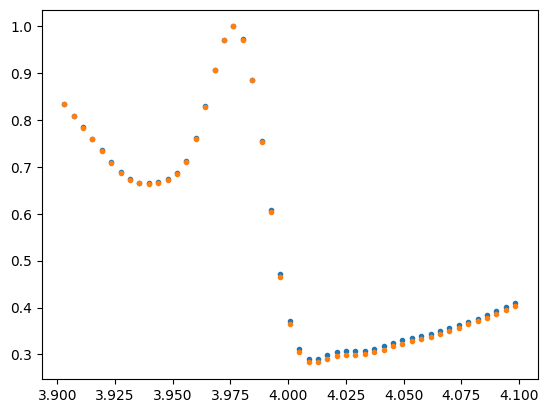

In [44]:
plt.plot(energy*1e-3, arrFI/np.max(arrFI), '.')
plt.plot(energy*1e-3, arrF/np.max(arrF), '.')
plt.show()

In [41]:
dw = w[1]-w[0]

dA = dw*1e3 * dw*1e3
dA

np.float64(0.00010203040506070766)

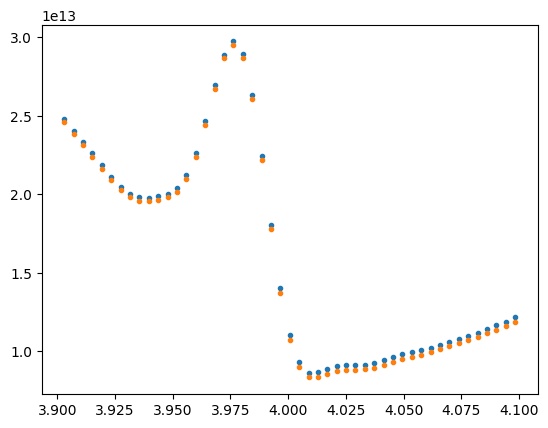

In [51]:
plt.plot(energy*1e-3, arrFI*dA, '.')
plt.plot(energy*1e-3, arrF, '.')
plt.show()

CONCLUSÃO: fluxo é de fato calculado como a integral da densidade de fluxo sobre a área. A distanção entre os gráficos possivelmente surge do uso de algum método numérico mais apropriado e robusto para calcular tal integral

# fluency manual calc

In [34]:
import numpy as np
from matplotlib import pyplot as plt

import srwave

In [23]:
und = srwave.Undulator(period_length=50e-3,nr_periods=20,Kv=2,Kh=0)
fields = srwave.MagnetCnt(magnets=[und],fieldtype='undulator')

w = np.linspace(-5e-4,5e-4,100)
harmns = np.linspace(0,11,177)[1:-1]
energy = und.harmonic_energy(harmn=harmns,E=3e9,theta=0)

SR = srwave.SynchrotronRadiation(energy=energy,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

In [30]:
harmns[15]

np.float64(1.0)

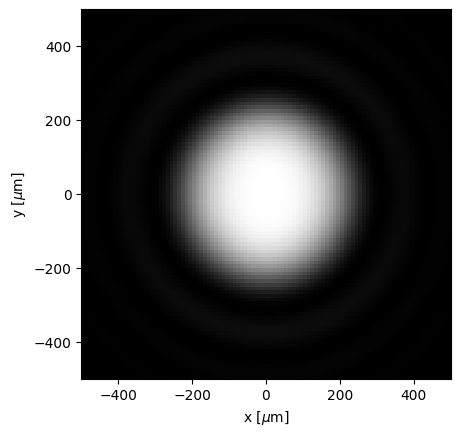

In [32]:
SR.plot_intensity(coords='xy',energy=energy[15])

In [39]:
arr, intervals = SR.calc_intensity(coords='xy', calctype='SE Fluence')
arr = arr.reshape(100,100)

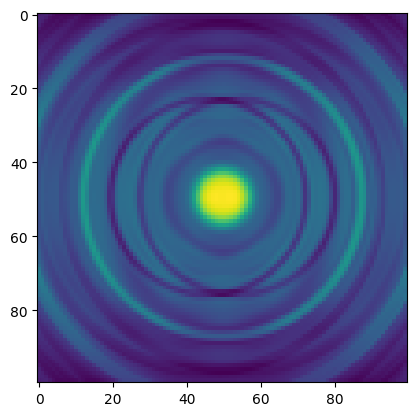

In [40]:
plt.imshow(arr)
plt.show()

# power

# unit of arE

# str e repr

In [1]:
import numpy as np

import srwave

In [2]:
arr = np.linspace(1,3,11)
arr

array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4, 2.6, 2.8, 3. ])

In [3]:
print(str(arr))

[1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3. ]


In [4]:
print(repr(arr))

array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4, 2.6, 2.8, 3. ])


In [2]:
energy = np.linspace(0.1, 100, 500) * 1e3

bm = srwave.BendingMagnet(B=1.4, L=3)
fields = srwave.MagnetCnt(magnets=bm, fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=energy, d=10, x=0, y=0, fields=fields)

In [3]:
print(SR)

Synchrotron Radiation

- - Mesh Grid - -
Photon Energy [keV] : 0.1 -- 100.0(500 points)
Horizontal    [um]  : 0.0 -- 0.0(1 points)
Vertical      [um]  : 0.0 -- 0.0(1 points)
Distance      [m]   : 10

- - - Beam - - -
Charge Energy [GeV] : 3.0
Current       [A]   : 0.1

- - Trajectory - -
None

- - Magnetic Field - -
Source     : bending
Field  [T] : 1.4


In [90]:
(
    "SynchrotronRadiation("
    f"ei={10e3}, ef={20e3}, ne={300},",
    f"xi={-50e-6}, xf={50e-6}, nx={21}, "
    f"yi={-20e-6}, yf={20e-6}, ny={51}"
    ")"
)

class representation:


    def __str__(self):

        titlestr = "Synchrotron Radiation\n"

        # mesh #
        ei, ef, ne = 10e3, 20e3, 11
        xi, xf, nx = -50e-6, 50e-6, 31
        yi, yf, ny = -20e-6, 20e-6, 201
        d = 10
        meshstr = (
            "- - Mesh Grid - -\n"
            f"Photon Energy [keV] : {ei*1e-3} -- {ef*1e-3} ({ne} points)\n"
            f"Horizontal    [um]  : {xi*1e6} -- {xf*1e6} ({nx} points)\n"
            f"Vertical      [um]  : {yi*1e6} -- {yf*1e6} ({ny} points)\n"
            f"Distance      [m]   : {d}\n"
        )
        
        # beam #
        E = 3e9
        I = 200e-3
        beamstr = (
            "- - - Beam - - -\n"
            f"Charge Energy [GeV] : {E*1e-9}\n"
            f"Current       [A]   : {I}\n"
        )

        # traj #
        trajstr = "- - Trajectory - -\n"
        traject = False
        if traject:
            pass
        else:
            trajstr += f"{None}\n"

        # mag #
        magstr = "- - Magnetic Field - -\n"
        fields = True
        fieldtype = 'bending'
        B = 1.4
        if fields:
            magstr += (
                f"Source : {fieldtype}\n"
                f"Field  : {B}"
            )
        else:
            magstr += f"{None}"

        return "\n".join([titlestr, meshstr, beamstr, trajstr, magstr])

    def __repr__(self):
        return ("SynchrotronRadiation(\n"
                f"\tei={10e3}, ef={20e3}, ne={11},\n"
                f"\txi={-50e-6}, xf={50e-6}, nx={31},\n"
                f"\tyi={-20e-6}, yf={20e-6}, ny={201},\n"
                f"\td={10},\n"
                f"\ttraj={None}\n"
                f"\tfields={None}\n"
                f"\tbeam={None}\n"
                ")")
    
a = representation()

print(a)

Synchrotron Radiation

- - Mesh Grid - -
Photon Energy [keV] : 10.0 -- 20.0 (11 points)
Horizontal    [um]  : -50.0 -- 50.0 (31 points)
Vertical      [um]  : -20.0 -- 20.0 (201 points)
Distance      [m]   : 10

- - - Beam - - -
Charge Energy [GeV] : 3.0
Current       [A]   : 0.2

- - Trajectory - -
None

- - Magnetic Field - -
Source : bending
Field  : 1.4


In [ ]:
np.array

array([   100.        ,    300.2004008 ,    500.4008016 ,    700.6012024 ,
          900.80160321,   1101.00200401,   1301.20240481,   1501.40280561,
         1701.60320641,   1901.80360721,   2102.00400802,   2302.20440882,
         2502.40480962,   2702.60521042,   2902.80561122,   3103.00601202,
         3303.20641283,   3503.40681363,   3703.60721443,   3903.80761523,
         4104.00801603,   4304.20841683,   4504.40881764,   4704.60921844,
         4904.80961924,   5105.01002004,   5305.21042084,   5505.41082164,
         5705.61122244,   5905.81162325,   6106.01202405,   6306.21242485,
         6506.41282565,   6706.61322645,   6906.81362725,   7107.01402806,
         7307.21442886,   7507.41482966,   7707.61523046,   7907.81563126,
         8108.01603206,   8308.21643287,   8508.41683367,   8708.61723447,
         8908.81763527,   9109.01803607,   9309.21843687,   9509.41883768,
         9709.61923848,   9909.81963928,  10110.02004008,  10310.22044088,
        10510.42084168,  

# gaussian beam total polarization

In [6]:
import numpy as np

import srwave

2


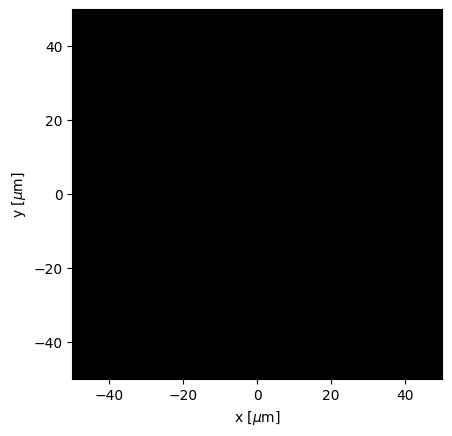

In [26]:
# TEM21 #

Eph = 8e3
w = np.linspace(-50,50,1000) * 1e-6

GR = srwave.GaussianRadiation(energy=Eph,x=w,y=w,d=2)
GR.gaussianbeam.set_mode(modex=1,modey=0)
GR.gaussianbeam.set_polarization(pol='pi')
print(GR.gaussianbeam.polar)
GR.calc_wfr()

GR.plot_intensity(coords='xy', energy=Eph, polarization='sigma')